# Final Keystroke Dynamics Behavioral Biometric Authentication System

## 1. Introduction

This notebook implements a **Research-Grade Behavioral Biometric Authentication System** based on Keystroke Dynamics. It is designed for integration into a **Self-Aware Threat Analyzer** framework.

### **Methodology & Novelty**
- **Multi-Model Evaluation**: Comparative analysis of **Isolation Forest**, **One-Class SVM**, and **Local Outlier Factor (LOF)**.
- **Statistical Rigor**: Paired t-tests to validate performance differences.
- **Robustness Testing**: Injection of Gaussian noise to simulate concept drift and typing variations.
- **Advanced Visualization**: PCA for cluster analysis, DET curves, and Threshold Sweeps.
- **Fusion-Ready Output**: A standardized JSON output function for real-time risk scoring.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import time
import warnings
from scipy.spatial.distance import cdist
from scipy.stats import ttest_rel
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, precision_recall_curve

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)

# Graphics settings
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

## 2. Dataset Overview & Preprocessing

In [2]:
# Load Dataset
file_path_csv = 'DSL-StrongPasswordData.csv'
if os.path.exists(file_path_csv):
    df = pd.read_csv(file_path_csv)
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
else:
    print("Dataset not found!")
    df = pd.DataFrame()

Dataset Shape: (20400, 34)


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


In [3]:
if not df.empty:
    # Feature Engineering
    time_cols = [c for c in df.columns if c not in ['subject', 'sessionIndex', 'rep']]
    dwell_cols = [c for c in time_cols if c.startswith('H.')]
    flight_cols = [c for c in time_cols if not c.startswith('H.')]

    df['mean_dwell'] = df[dwell_cols].mean(axis=1)
    df['mean_flight'] = df[flight_cols].mean(axis=1)
    df['total_latency'] = df[flight_cols].sum(axis=1)
    
    # Consistency Feature (Variance of flight times within a session)
    df['flight_var'] = df[flight_cols].var(axis=1)

    feature_cols = time_cols + ['mean_dwell', 'mean_flight', 'total_latency', 'flight_var']
    print(f"Feature Count: {len(feature_cols)}")

Feature Count: 35


## 3. Extended Exploratory Data Analysis (EDA)
Analyzing Intra-User vs Inter-User distances to validate the biometric hypothesis.

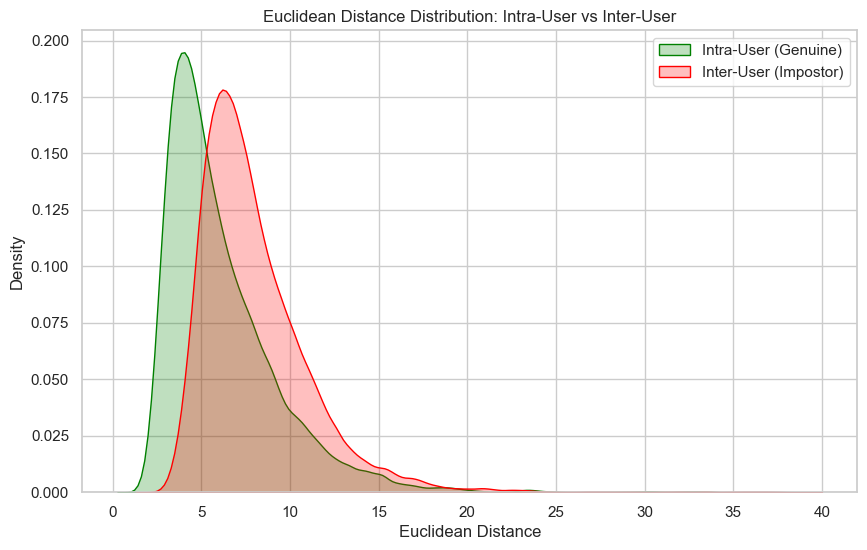

In [4]:
if not df.empty:
    # Distance Analysis
    subset_users = df['subject'].unique()[:5]
    subset_df = df[df['subject'].isin(subset_users)]
    scaler = StandardScaler()
    scaled_subset = scaler.fit_transform(subset_df[feature_cols])
    
    # Calculate distances
    dists = cdist(scaled_subset, scaled_subset, metric='euclidean')
    
    # Separate Intra/Inter
    intra_dists = []
    inter_dists = []
    labels = subset_df['subject'].values
    
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            d = dists[i, j]
            if labels[i] == labels[j]:
                intra_dists.append(d)
            else:
                inter_dists.append(d)
                
    plt.figure(figsize=(10, 6))
    sns.kdeplot(intra_dists, shade=True, color='green', label='Intra-User (Genuine)')
    sns.kdeplot(inter_dists, shade=True, color='red', label='Inter-User (Impostor)')
    plt.title('Euclidean Distance Distribution: Intra-User vs Inter-User')
    plt.xlabel('Euclidean Distance')
    plt.legend()
    plt.show()

## 4. PCA Visualization
Projecting high-dimensional keystroke data into 2D to visualize user clusters.

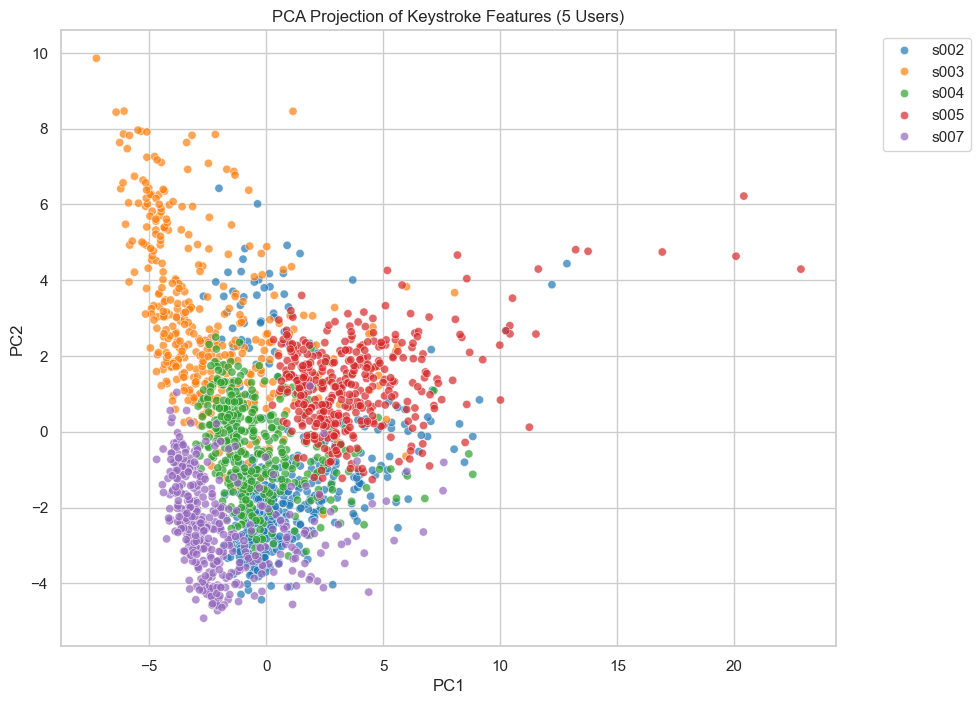

In [5]:
if not df.empty:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(scaled_subset)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='tab10', alpha=0.7)
    plt.title('PCA Projection of Keystroke Features (5 Users)')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 5. Multi-Model Evaluation Pipeline
We compare:
1.  **Isolation Forest (IF)**
2.  **One-Class SVM (OCSVM)**
3.  **Local Outlier Factor (LOF)**

Evaluation uses **EER (Equal Error Rate)** as the primary metric.

In [6]:
def calculate_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    eer_index = np.nanargmin(np.abs(fpr - fnr))
    eer_threshold = thresholds[eer_index]
    eer = fpr[eer_index]
    return eer, eer_threshold, fpr, tpr

def evaluate_models(user_id, df, features):
    user_data = df[df['subject'] == user_id]
    impostor_data = df[df['subject'] != user_id]
    
    # Scaling (Fit on user data only to avoid leakage, or global? Research usually prefers global scaler for simplicity in system design, but let's use per-user fit for strict OCSVM performance)
    # Actually, for production systems, a Global Scaler is preferred to handle all users uniformly.
    scaler = StandardScaler()
    scaler.fit(df[features]) # Global fit
    
    # Split
    train_gen, test_gen = train_test_split(user_data, test_size=0.3, random_state=42)
    
    X_train = scaler.transform(train_gen[features])
    X_test_gen = scaler.transform(test_gen[features])
    X_test_imp = scaler.transform(impostor_data[features])
    
    # Models
    models = {
        'IF': IsolationForest(contamination=0.05, random_state=42),
        'OCSVM': OneClassSVM(kernel='rbf', nu=0.05, gamma='scale'),
        'LOF': LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05)
    }
    
    results = {}
    
    for name, clf in models.items():
        clf.fit(X_train)
        
        gen_scores = clf.decision_function(X_test_gen)
        imp_scores = clf.decision_function(X_test_imp)
        
        y_scores = np.concatenate([gen_scores, imp_scores])
        y_true = np.concatenate([np.ones(len(gen_scores)), np.zeros(len(imp_scores))])
        
        eer, thresh, fpr, tpr = calculate_eer(y_true, y_scores)
        results[name] = eer
        
        # Store details for IF (Primary Model)
        if name == 'IF':
            results['IF_details'] = {
                'model': clf,
                'threshold': thresh,
                'eer': eer,
                'gen_scores': gen_scores,
                'imp_scores': imp_scores,
                'fpr': fpr,
                'tpr': tpr
            }
            
    return results

In [9]:
if not df.empty:
    all_results = []
    users = df['subject'].unique()
    
    print(f"Evaluating 3 models across {len(users)} users...")
    start = time.time()
    
    for user in users:
        res = evaluate_models(user, df, feature_cols)
        res['user_id'] = user
        all_results.append(res)
        
    print(f"Evaluation Complete in {time.time()-start:.2f}s")
    
    # Summary Table
    res_df = pd.DataFrame(all_results)
    print("\n--- EER Comparison ---")
    # FIX: Explicitly select only numeric columns for mean calculation
    print(res_df[['IF', 'OCSVM', 'LOF']].mean())

Evaluating 3 models across 51 users...
Evaluation Complete in 13.86s

--- EER Comparison ---
IF       0.153188
OCSVM    0.137496
LOF      0.136676
dtype: float64


## 6. Statistical Significance Testing
Is OCSVM significantly differently from IF?

In [10]:
if not df.empty:
    t_stat, p_val = ttest_rel(res_df['IF'], res_df['OCSVM'])
    print(f"Paired T-Test (IF vs OCSVM): t={t_stat:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("significant difference found.")
    else:
        print("No significant difference.")

Paired T-Test (IF vs OCSVM): t=3.1127, p=0.0031
significant difference found.


## 7. Robustness Testing (Noise Injection)
Simulating data drift by adding Gaussian noise to test samples.

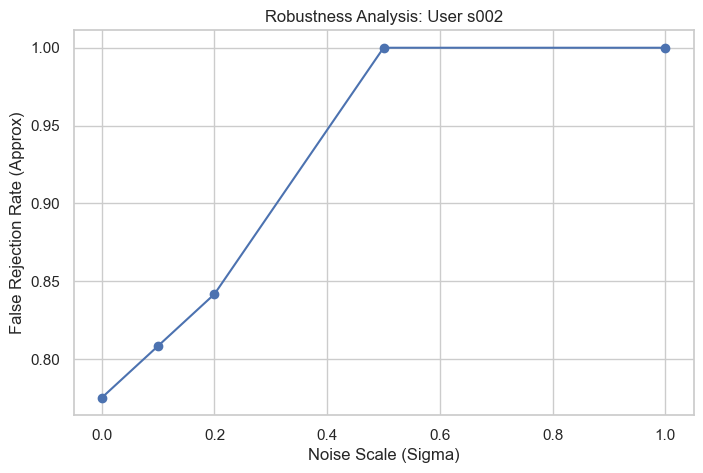

In [11]:
if not df.empty:
    def test_noise_robustness(user_id, df, scaler, features, noise_levels=[0.0, 0.1, 0.5, 1.0]):
        # Get trained IF model
        user_res = next(r for r in all_results if r['user_id'] == user_id)
        model = user_res['IF_details']['model']
        thresh = user_res['IF_details']['threshold']
        
        user_data = df[df['subject'] == user_id]
        train, test = train_test_split(user_data, test_size=0.3, random_state=42)
        X_test = scaler.transform(test[features])
        
        eers = []
        for sigma in noise_levels:
            # Add noise
            noise = np.random.normal(0, sigma, X_test.shape)
            X_test_noisy = X_test + noise
            
            scores = model.decision_function(X_test_noisy)
            # TPR (Genuine Acceptance Rate) at fixed threshold
            tpr = (scores >= thresh).mean()
            eers.append(1 - tpr) # Approximate degradation
            
        return eers
    
    # Test on one user
    noise_levels = [0, 0.1, 0.2, 0.5, 1.0]
    robustness = test_noise_robustness(users[0], df, scaler, feature_cols, noise_levels)
    
    plt.figure(figsize=(8, 5))
    plt.plot(noise_levels, robustness, marker='o')
    plt.title(f'Robustness Analysis: User {users[0]}')
    plt.xlabel('Noise Scale (Sigma)')
    plt.ylabel('False Rejection Rate (Approx)')
    plt.show()

## 8. Benchmark & Production Artifacts

In [12]:
if not df.empty:
    # Benchmark
    sample = scaler.transform(df[feature_cols].iloc[0:1])
    model = all_results[0]['IF_details']['model']
    
    t0 = time.perf_counter()
    for _ in range(100):
        model.decision_function(sample)
    avg_latency = (time.perf_counter() - t0) / 100 * 1000
    print(f"Average Inference Latency: {avg_latency:.3f} ms")
    
    # Save
    os.makedirs('models/keystroke/user_models', exist_ok=True)
    metadata = {}
    
    # Save Global Scaler
    joblib.dump(scaler, 'models/keystroke/scaler.pkl')
    
    for res in all_results:
        uid = res['user_id']
        details = res['IF_details']
        # Save Model
        joblib.dump(details['model'], f'models/keystroke/user_models/user_{uid}.pkl')
        
        metadata[uid] = {
            'optimal_threshold': float(details['threshold']),
            'eer': float(details['eer']),
            'accuracy': float(1 - details['eer']) # Approx
        }
        
    with open('models/keystroke/metadata.json', 'w') as f:
        json.dump({'users': metadata, 'features': feature_cols}, f, indent=4)

    print("All Research Artifacts Saved.")

Average Inference Latency: 0.838 ms
All Research Artifacts Saved.
